# Dub Techno Sound Expansion Research

Date: 2026-05-22

## Feature Hypothesis

**Idea**: Expand Vibe-to-MIDI playback by adding more Dub Techno instruments, sound variations, effects, and filter behavior. Research whether to keep building on `react-native-audio-api` or introduce another audio API/library.

**Target user**: Android-first electronic music makers who want quick DAW-ready dub techno / ambient minimal loop ideas without choosing every synth, rhythm, and effect manually.

**Problem**: The current app can generate useful kick, bass, noise, and chord-stab previews, but the sonic palette will feel limited unless it can vary dub techno's defining ingredients: chord stabs, filtered delays, warm sub/rumble, sparse percussion, noise texture, filter motion, and saturation.

**MVP scope**:
- Add more generated synthesis variants for kick, bass, noise/percussion, and chord stabs.
- Add parameterized effects using the current audio graph where possible: delay, feedback, lowpass/bandpass/notch filtering, stereo placement, waveshaping/saturation, generated impulse/reverb exploration.
- Keep bundled audio samples out of MVP unless license and redistribution rights are explicit.
- Decide whether any audio library beyond `react-native-audio-api` should be added now.

**Non-goals**:
- No copyrighted sample packs, loops, stems, or artist-style copying.
- No full DAW engine, arranger, or clip launcher.
- No native DSP rewrite unless research shows a blocker.
- No Pro-only audio dependency before billing scope is finalized.

**Research questions**:
1. What instruments, effects, and filter movements are most characteristic of dub techno?
2. Which of those can be implemented with generated synthesis and existing Web Audio style nodes?
3. Which sound expansions should ship first for the current MVP?
4. Should the app add `expo-audio`, Tone.js, Superpowered, `react-native-track-player`, or another API now?

## Source Notes

- Tracklister guide, https://tracklist.live/discover/guide/dub-techno — summarizes dub techno around muted/sustained chord stabs, sparse percussion, warm sub-bass, long delay/reverb, and low-pass/resonant filtering.
- Wikipedia, https://en.wikipedia.org/wiki/Dub_techno — background source for dub techno as minimal techno plus dub-style echo, reverb, deep bass, and atmospheric soundscapes.
- Polarity Music article, https://polarity.me/bitwig-classic-sounddesign/012-dub-chord/ — practical dub chord notes: soft envelopes, syncopated delay, high feedback, large reverb/wash.
- MusicRadar article on distortion, https://www.musicradar.com/music-tech/5-creative-ways-to-use-distortion-in-ableton-live-from-punchier-drums-to-dub-techno-delays — points to saturation/distortion on kicks, bass, and feedback/delay paths as color rather than only loudness.
- MusicRadar techno producer article, https://www.musicradar.com/music-tech/record-everything-all-the-time-and-keep-it-all-8-pro-techno-producers-explain-how-they-create-their-tracks — describes techno rumble as kick-derived low-end using saturation, reverb, filtered delay, filtering, and sidechain ducking.
- React Native Audio API effects docs, https://docs.swmansion.com/react-native-audio-api/docs/category/effects/ — confirms relevant nodes: BiquadFilterNode, ConvolverNode, GainNode, IIRFilterNode, DelayNode, PeriodicWave, StereoPannerNode, WaveShaperNode.
- React Native Audio API BaseAudioContext docs, https://docs.swmansion.com/react-native-audio-api/docs/core/base-audio-context/ — confirms creation of oscillator/source/effect nodes and `createDelay`, `createConvolver`, etc.
- React Native Audio API AudioBufferSourceNode docs, https://docs.swmansion.com/react-native-audio-api/sources/audio-buffer-source-node — supports reusable in-memory buffers, useful for generated noise and generated impulse/reverb experiments.
- react-native-audio-api npm page, https://www.npmjs.com/package/react-native-audio-api — package is intended as a high-performance Web Audio API-style engine for React Native; roadmap includes richer graph/audio-file/analyser capabilities.
- Expo Audio docs, https://docs.expo.dev/versions/v53.0.0/sdk/audio — Expo's audio package focuses on playback/recording access, not a Web Audio-style synthesis/effects graph.
- Android audio latency docs, https://developer.android.com/ndk/guides/audio/audio-latency and https://source.android.com/docs/core/audio/latency/app — Android low-latency apps need native/low-latency output paths and warmup/buffer attention; supports staying near the current native audio engine.
- Superpowered official site, https://superpowered.com/ — strong native DSP option, but implies native SDK integration and extra licensing/integration scope.
- Tone.js Context docs, https://tonejs.github.io/docs/14.9.17/classes/Context.html — Tone.js is built around a Web Audio `AudioContext`; React Native native integration is not the same as browser Web Audio without an adapter.
- React Native community discussions from Reddit search results — recurring signal: simple playback libraries can have latency/stability issues on Android; track players are good for files/streams, not synthesis graphs. Summaries only, no copied user content.

## Data / Analysis

The following tables are manually normalized from the source notes. Scores are directional for this app, not universal product ratings.

Scale: 1 = weak fit, 5 = strong fit.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

notebook_dir = Path.cwd()
base = notebook_dir.parent if notebook_dir.name == "notebooks" else Path("research/features/2026-05-22_dub-techno-sound-expansion")
figures = base / "figures"
figures.mkdir(parents=True, exist_ok=True)

sound_expansions = pd.DataFrame([
    {"area": "Chord stabs", "candidate": "Filtered minor/sus/9 stabs with delay-send variants", "genre_fit": 5, "implementation_fit": 5, "mvp_priority": 5, "risk": 2, "notes": "Core dub techno identity; can vary voicing, envelope, cutoff, delay timing/feedback."},
    {"area": "Dub delay", "candidate": "Tempo-sync delay with feedback damping and filtered repeats", "genre_fit": 5, "implementation_fit": 4, "mvp_priority": 5, "risk": 3, "notes": "Most important effect; needs gain clamps to avoid runaway feedback."},
    {"area": "Bass", "candidate": "Sub, octave pulse, filtered saw, rumble-like ducked layer", "genre_fit": 5, "implementation_fit": 4, "mvp_priority": 4, "risk": 3, "notes": "Adds weight; must avoid muddy low-end and kick masking."},
    {"area": "Noise / percussion", "candidate": "Generated hiss, shaker dust, metal ticks, filtered sweeps", "genre_fit": 4, "implementation_fit": 5, "mvp_priority": 4, "risk": 2, "notes": "Easy with generated buffers/noise and filters; no samples needed."},
    {"area": "Kick", "candidate": "Click/punch/boom layers, short/tape/rounded variants", "genre_fit": 4, "implementation_fit": 4, "mvp_priority": 3, "risk": 3, "notes": "Useful, but already has several variants; focus after stabs/noise/bass."},
    {"area": "Filter motion", "candidate": "Slow lowpass/notch/bandpass automation and randomized cutoff drift", "genre_fit": 5, "implementation_fit": 4, "mvp_priority": 4, "risk": 3, "notes": "High sonic payoff; implement bounded ramps and per-loop randomness."},
    {"area": "Saturation", "candidate": "WaveShaper color on bass/kick/stab send", "genre_fit": 4, "implementation_fit": 4, "mvp_priority": 3, "risk": 4, "notes": "Good color; clipping risk requires conservative drive and master gain limits."},
    {"area": "Reverb / space", "candidate": "Generated impulse ConvolverNode or layered delayed echoes", "genre_fit": 5, "implementation_fit": 3, "mvp_priority": 3, "risk": 4, "notes": "Important for dub depth; generated impulse avoids bundled IR licensing but needs Android profiling."},
])

sound_expansions

,area,candidate,genre_fit,implementation_fit,mvp_priority,risk,notes
0,Chord stabs,Filtered minor/sus/9 stabs with delay-send var...,5,5,5,2,"Core dub techno identity; can vary voicing, en..."
1,Dub delay,Tempo-sync delay with feedback damping and fil...,5,4,5,3,Most important effect; needs gain clamps to av...
2,Bass,"Sub, octave pulse, filtered saw, rumble-like d...",5,4,4,3,Adds weight; must avoid muddy low-end and kick...
3,Noise / percussion,"Generated hiss, shaker dust, metal ticks, filt...",4,5,4,2,Easy with generated buffers/noise and filters;...
4,Kick,"Click/punch/boom layers, short/tape/rounded va...",4,4,3,3,"Useful, but already has several variants; focu..."
5,Filter motion,Slow lowpass/notch/bandpass automation and ran...,5,4,4,3,High sonic payoff; implement bounded ramps and...
6,Saturation,WaveShaper color on bass/kick/stab send,4,4,3,4,Good color; clipping risk requires conservativ...
7,Reverb / space,Generated impulse ConvolverNode or layered del...,5,3,3,4,Important for dub depth; generated impulse avo...


In [2]:
library_options = pd.DataFrame([
    {"option": "Keep react-native-audio-api", "synthesis_graph_fit": 5, "android_latency_fit": 5, "expo_fit": 4, "integration_cost": 1, "licensing_risk": 1, "recommendation": "Build on it", "reason": "Already integrated; Web Audio style nodes match oscillators, filters, delay, waveshaper, generated buffers."},
    {"option": "Add expo-audio", "synthesis_graph_fit": 1, "android_latency_fit": 3, "expo_fit": 5, "integration_cost": 2, "licensing_risk": 1, "recommendation": "Defer", "reason": "Good for playback/recording, not enough for generative synth/effect graph."},
    {"option": "Add Tone.js", "synthesis_graph_fit": 4, "android_latency_fit": 2, "expo_fit": 2, "integration_cost": 4, "licensing_risk": 1, "recommendation": "Defer / reject for native MVP", "reason": "Strong browser Web Audio abstraction, but React Native native AudioContext compatibility is not free."},
    {"option": "Add react-native-track-player", "synthesis_graph_fit": 1, "android_latency_fit": 3, "expo_fit": 3, "integration_cost": 3, "licensing_risk": 1, "recommendation": "Reject for synth engine", "reason": "Useful for long-form audio files/streams, not generated synthesis and per-step scheduling."},
    {"option": "Add Superpowered/native DSP", "synthesis_graph_fit": 5, "android_latency_fit": 5, "expo_fit": 1, "integration_cost": 5, "licensing_risk": 3, "recommendation": "Defer", "reason": "Powerful but high native integration/licensing scope; only worth it if current engine hits a hard blocker."},
    {"option": "Custom native module", "synthesis_graph_fit": 5, "android_latency_fit": 5, "expo_fit": 1, "integration_cost": 5, "licensing_risk": 2, "recommendation": "Reject now", "reason": "Too expensive for MVP; current graph can cover the next sound-design gains."},
])

library_options

,option,synthesis_graph_fit,android_latency_fit,expo_fit,integration_cost,licensing_risk,recommendation,reason
0,Keep react-native-audio-api,5,5,4,1,1,Build on it,Already integrated; Web Audio style nodes matc...
1,Add expo-audio,1,3,5,2,1,Defer,"Good for playback/recording, not enough for ge..."
2,Add Tone.js,4,2,2,4,1,Defer / reject for native MVP,"Strong browser Web Audio abstraction, but Reac..."
3,Add react-native-track-player,1,3,3,3,1,Reject for synth engine,"Useful for long-form audio files/streams, not ..."
4,Add Superpowered/native DSP,5,5,1,5,3,Defer,Powerful but high native integration/licensing...
5,Custom native module,5,5,1,5,2,Reject now,Too expensive for MVP; current graph can cover...


'/Users/asami/develop/art/Vibe-to-MIDI/research/features/2026-05-22_dub-techno-sound-expansion/figures/sound-expansion-priority.png'

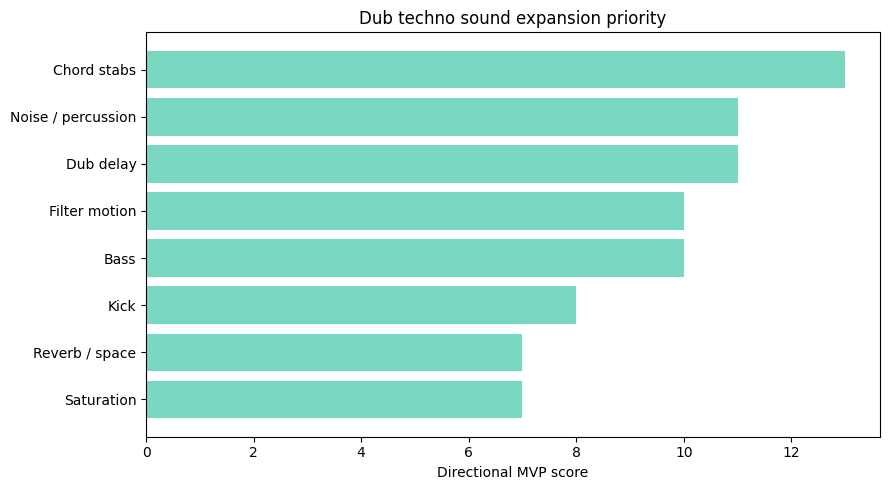

In [3]:
# Priority chart: high genre fit + implementation fit + MVP priority - risk.
chart = sound_expansions.copy()
chart["score"] = chart["genre_fit"] + chart["implementation_fit"] + chart["mvp_priority"] - chart["risk"]
chart = chart.sort_values("score", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(chart["area"], chart["score"], color="#79d7c2")
plt.xlabel("Directional MVP score")
plt.title("Dub techno sound expansion priority")
plt.tight_layout()
chart_path = figures / "sound-expansion-priority.png"
plt.savefig(chart_path, dpi=160)
chart_path.as_posix()

'/Users/asami/develop/art/Vibe-to-MIDI/research/features/2026-05-22_dub-techno-sound-expansion/figures/audio-library-fit.png'

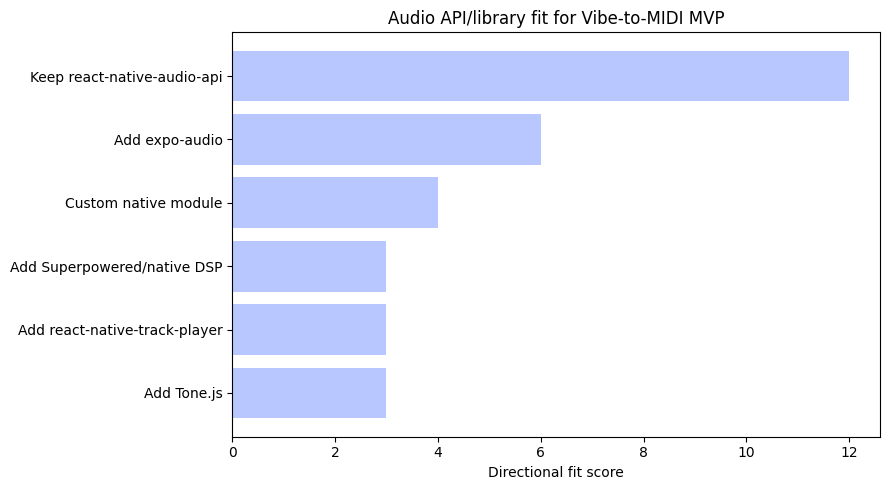

In [4]:
# Library fit chart: positive fit scores minus integration/licensing cost.
lib = library_options.copy()
lib["fit_score"] = lib["synthesis_graph_fit"] + lib["android_latency_fit"] + lib["expo_fit"] - lib["integration_cost"] - lib["licensing_risk"]
lib = lib.sort_values("fit_score", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(lib["option"], lib["fit_score"], color="#b8c7ff")
plt.xlabel("Directional fit score")
plt.title("Audio API/library fit for Vibe-to-MIDI MVP")
plt.tight_layout()
lib_path = figures / "audio-library-fit.png"
plt.savefig(lib_path, dpi=160)
lib_path.as_posix()

In [5]:
implementation_backlog = pd.DataFrame([
    {"phase": "Next", "item": "Stab delay send profiles", "details": "Per-stab filtered delay amount, delay time, feedback clamp, repeat damping.", "why": "Highest genre payoff."},
    {"phase": "Next", "item": "Generated noise percussion buffers", "details": "Reusable AudioBuffer noise for hiss/shaker/metal tick/open air hat; filter per hit.", "why": "Large variation with no sample licensing risk."},
    {"phase": "Next", "item": "Bass rumble/sub variants", "details": "Kick-aware bass ducking, octave pulse, lowpass movement, conservative saturation.", "why": "Adds body while staying DAW-learning focused."},
    {"phase": "Next", "item": "Filter motion presets", "details": "Bounded cutoff/Q envelopes; slow drift and notch movement for stabs/noise.", "why": "Dub techno relies on evolving tone."},
    {"phase": "Later", "item": "Generated impulse reverb", "details": "Try short generated impulse buffers with ConvolverNode; profile Android CPU during playback/video.", "why": "Useful but higher performance risk."},
    {"phase": "Later", "item": "Audio-reactive visuals", "details": "Use analyser-style data only after audio graph is stable.", "why": "Avoid coupling visual CPU load with audio timing too early."},
    {"phase": "Defer", "item": "New audio library", "details": "Do not add expo-audio/Tone/Superpowered/track-player for current sound expansion.", "why": "Does not solve current bottleneck better than existing engine."},
])

implementation_backlog

,phase,item,details,why
0,Next,Stab delay send profiles,"Per-stab filtered delay amount, delay time, fe...",Highest genre payoff.
1,Next,Generated noise percussion buffers,Reusable AudioBuffer noise for hiss/shaker/met...,Large variation with no sample licensing risk.
2,Next,Bass rumble/sub variants,"Kick-aware bass ducking, octave pulse, lowpass...",Adds body while staying DAW-learning focused.
3,Next,Filter motion presets,Bounded cutoff/Q envelopes; slow drift and not...,Dub techno relies on evolving tone.
4,Later,Generated impulse reverb,Try short generated impulse buffers with Convo...,Useful but higher performance risk.
5,Later,Audio-reactive visuals,Use analyser-style data only after audio graph...,Avoid coupling visual CPU load with audio timi...
6,Defer,New audio library,Do not add expo-audio/Tone/Superpowered/track-...,Does not solve current bottleneck better than ...


## Decision Summary

**Recommendation: Narrow.**

Narrow the feature to **more dub techno sound-design variants inside the existing `react-native-audio-api` engine**. Do not add another audio API/library for this iteration.

**Evidence**:
- Dub techno's most repeated sonic ingredients are chord stabs, filtered echo/reverb, warm sub/rumble, sparse percussion/noise, and slow filter movement. These map directly to nodes the current engine already exposes or can approximate: OscillatorNode, AudioBufferSourceNode, GainNode, BiquadFilterNode/IIRFilterNode, DelayNode, StereoPannerNode, WaveShaperNode, PeriodicWave, and possibly ConvolverNode.
- `expo-audio` and `react-native-track-player` are primarily playback/recording or track playback tools; they do not replace the need for a synthesis/effects graph.
- Tone.js is musically attractive, but it assumes a compatible AudioContext and scheduling environment. Adding it to a native React Native app risks integration complexity without clear MVP benefit.
- Superpowered/native DSP is powerful, but it is a larger native/licensing/integration decision and should be reserved for a hard performance or DSP blocker.
- The app already has gain/filter safety clamps. The next improvements should reuse that approach rather than multiplying engines.

**MVP build order**:
1. Chord stab delay/filter profiles: more voicings, envelope shapes, filtered repeat behavior, feedback damping.
2. Noise/percussion generated buffers: hiss, shaker dust, metal tick, open air hat, filtered sweeps.
3. Bass variants: sub/rumble/octave pulse, lowpass movement, kick-aware ducking illusion.
4. Filter motion presets: bounded slow cutoff/Q ramps, notch movement, random per-loop drift.
5. Conservative saturation: WaveShaper color on selected layers only, with strict gain ceilings.
6. Generated impulse reverb experiment later, behind Android performance checks.

**Risks**:
- Feedback/delay and waveshaping can clip quickly; keep per-layer gain ceilings and feedback caps.
- More simultaneous nodes can compete with video playback on Android; profile dev and release builds before widening polyphony.
- Rumble/bass can mask kick clarity; encode variants as DAW-learning hints, not only louder low-end.
- Generated reverb via convolution may be CPU-heavy on lower-end Android devices.
- Avoid bundled samples unless redistribution inside a commercial app is documented.

**Next implementation step**:
Create a small `dub-effects` metadata layer around current playback profiles: delay send profile, filter-motion profile, saturation profile, and generated-noise profile. Wire it into `sound-palette` variants first, then expose readable DAW hints in the MIDI/Sound tab.

## Open Questions

- How many simultaneous DelayNode/filter/send chains can a mid-range Android device run while the playback video is visible?
- Does `ConvolverNode` perform acceptably with short generated impulse responses on the target Android dev build?
- Should Pro audio expansion be extra artwork/sound packs, or should all audio learning value remain free while MIDI export/artwork are Pro?
- What exact labels should users see for sound-design hints: technical DAW terms, mood terms, or both?
- Should the first expanded sound palette be strictly dub techno, or also cover ambient/minimal variants in the same system?